In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor
from torchvision.transforms import Resize, InterpolationMode
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

def get_clip_embeddings(images_np, batch_size=64):
    """
    Convert numpy array of images to CLIP embeddings using Hugging Face Transformers
    :param images_np: Input array of shape (N, 3, 128, 128) with values 0-255
    :param batch_size: Processing batch size (adjust based on GPU memory)
    :return: Numpy array of embeddings (N, 768)
    """
    # Load model and processor
    model_name = "openai/clip-vit-large-patch14"
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device).eval()
    
    # Preprocessing parameters
    resize = Resize((224, 224), interpolation=InterpolationMode.BICUBIC)
    mean = torch.tensor(processor.feature_extractor.image_mean).view(1, 3, 1, 1).to(device)
    std = torch.tensor(processor.feature_extractor.image_std).view(1, 3, 1, 1).to(device)
    
    # Convert to tensor and normalize
    images_tensor = torch.from_numpy(images_np).float().div(255)
    
    embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(images_tensor), batch_size), position=0, leave=True):
            batch = images_tensor[i:i+batch_size].to(device)
            
            # Resize and normalize
            processed_batch = (resize(batch) - mean) / std
            
            # Get embeddings
            features = model.get_image_features(pixel_values=processed_batch)
            features = features / features.norm(dim=-1, keepdim=True)
            embeddings.append(features.cpu().numpy())
    
    return np.concatenate(embeddings, axis=0)


DATASETS_PATH = '/home/alexander/external_storage/alexander/DATA/sk_integration/data/grid_generation/' #CHANGE HERE

states = np.load(DATASETS_PATH+"states.npy",)

embeddings = get_clip_embeddings(states)
# embeddings = np.load(DATASETS_PATH+'states_clip_embeddings.npy')

print(f"Input shape: {states.shape}")
print(f"Output shape: {embeddings.shape}")

np.save(DATASETS_PATH+"states_clip_embeddings.npy", embeddings)

Input shape: (60105, 3, 128, 128)
Output shape: (60105, 768)


# CLIP distance distribution 
You can use distance between clip vectors to define distributions 

This is an example, compute_clip_based_posteriors.py generates all distributions 

In [ ]:
DATASETS_PATH = 'data/grid_generation/' #CHANGE HERE

states_clip_embeddings = np.load(DATASETS_PATH+"states_clip_embeddings.npy",)
labels = np.load(DATASETS_PATH+"labels.npy",)
states = np.load(DATASETS_PATH+"states.npy",)


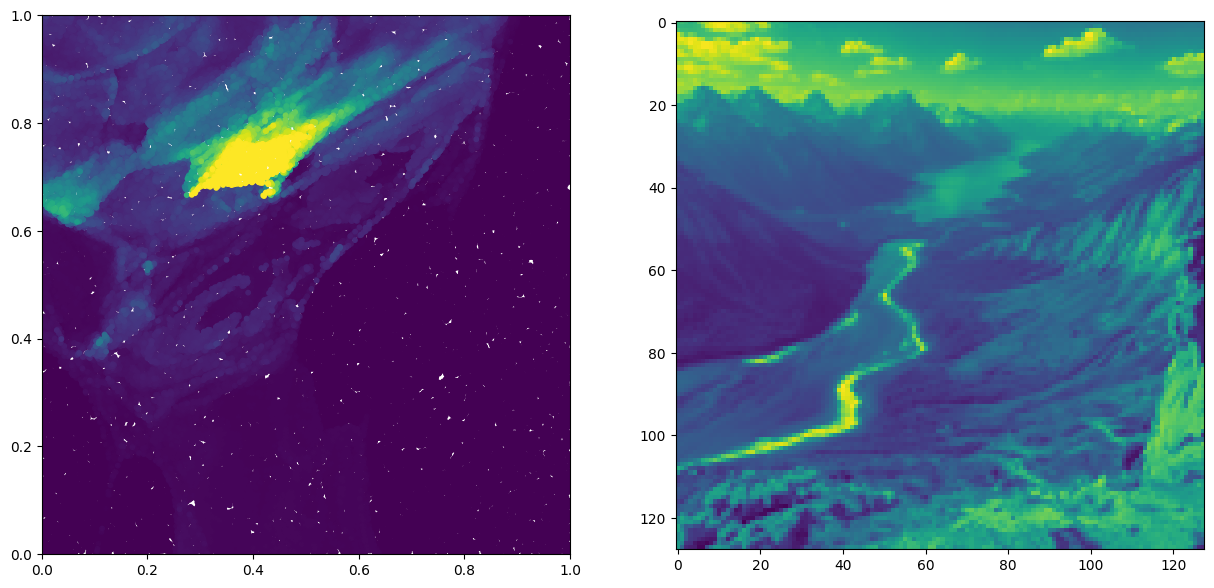

In [392]:
idx = np.random.randint(len(states_clip_embeddings))

dists = np.sqrt(2*(1.00001-states_clip_embeddings@states_clip_embeddings[idx]))
dists = np.exp(-10*dists)

idxes = np.argsort(dists)[::1]

plt.figure(figsize=(15,7))
plt.subplot(121)
plt.scatter(labels[idxes,0], 1-labels[idxes,1], c=dists[idxes], s=10, vmin=0, vmax=1/5)
plt.xlim(0,1)
plt.ylim(0,1)
plt.subplot(122)
plt.imshow(states[idx].mean(0))
plt.show()